In [1]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

print("Kaggle connected successfully!")


Kaggle connected successfully!


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [3]:

!kaggle datasets download tongpython/cat-and-dog -p data --unzip


Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0




  0%|          | 0.00/218M [00:00<?, ?B/s]
  0%|          | 1.00M/218M [00:01<05:31, 687kB/s]
  1%|          | 2.00M/218M [00:01<02:45, 1.37MB/s]
  1%|▏         | 3.00M/218M [00:01<01:42, 2.20MB/s]
  2%|▏         | 5.00M/218M [00:02<00:55, 4.05MB/s]
  3%|▎         | 7.00M/218M [00:02<00:40, 5.47MB/s]
  4%|▍         | 9.00M/218M [00:02<00:30, 7.15MB/s]
  5%|▍         | 10.0M/218M [00:02<00:28, 7.65MB/s]
  6%|▌         | 12.0M/218M [00:02<00:23, 9.02MB/s]
  6%|▋         | 14.0M/218M [00:02<00:21, 9.82MB/s]
  7%|▋         | 16.0M/218M [00:03<00:20, 10.5MB/s]
  8%|▊         | 18.0M/218M [00:03<00:19, 10.9MB/s]
  9%|▉         | 20.0M/218M [00:03<00:18, 11.1MB/s]
 10%|█         | 22.0M/218M [00:03<00:17, 11.4MB/s]
 11%|█         | 24.0M/218M [00:03<00:17, 11.4MB/s]
 12%|█▏        | 26.0M/218M [00:03<00:17, 11.5MB/s]
 13%|█▎        | 28.0M/218M [00:04<00:17, 11.7MB/s]
 14%|█▍        | 30.0M/218M [00:04<00:17, 11.3MB/s]
 15%|█▍        | 32.0M/218M [00:04<00:17, 11.4MB/s]
 16%|█▌        | 34.0

In [4]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/training_set",
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/test_set",
    image_size=(224, 224),
    batch_size=32
)


Found 8005 files belonging to 1 classes.
Found 2023 files belonging to 1 classes.


In [5]:
import os

print(os.listdir("data"))


['test_set', 'training_set']


In [6]:
print(os.listdir("data/training_set"))


['training_set']


In [7]:
import os
print(os.listdir("data/training_set"))


['training_set']


In [8]:
print(os.listdir("data/training_set/training_set"))


['cats', 'dogs']


In [9]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/training_set/training_set",
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data/test_set/test_set",
    image_size=(224, 224),
    batch_size=32
)


Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [11]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 613ms/step - accuracy: 0.9545 - loss: 0.1053 - val_accuracy: 0.9758 - val_loss: 0.0608
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 582ms/step - accuracy: 0.9898 - loss: 0.0301 - val_accuracy: 0.9797 - val_loss: 0.0577
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 586ms/step - accuracy: 0.9933 - loss: 0.0208 - val_accuracy: 0.9827 - val_loss: 0.0504
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 578ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.9827 - val_loss: 0.0544
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 145s 578ms/step - accuracy: 0.9983 - loss: 0.0070 - val_accuracy: 0.9852 - val_loss: 0.0527


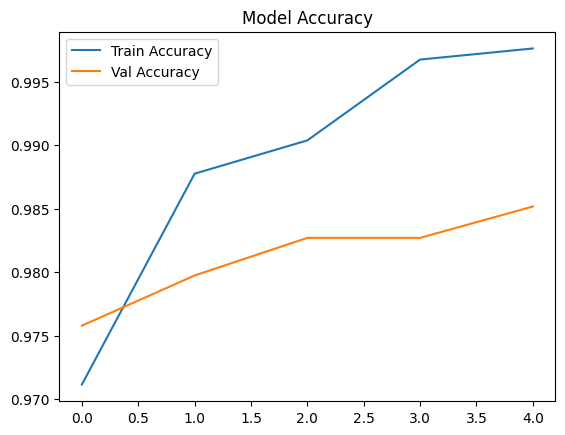

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Val Accuracy'])
plt.title("Model Accuracy")
plt.show()


In [16]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Final Training Accuracy: 0.9976264834403992
Final Validation Accuracy: 0.9851705431938171


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "image.png"  # put any cat or dog image here

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0


In [18]:
prediction = model.predict(img_array)

class_names = ['cat', 'dog']
print("Prediction:", class_names[np.argmax(prediction)])
print("Confidence:", np.max(prediction) * 100, "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step
Prediction: dog
Confidence: 99.91937279701233 %


In [19]:
model.save("cats_vs_dogs_basic_model.h5")


In [20]:
model.save("cats_vs_dogs_basic_model.keras")
